# Dự đoán khả năng sống sót của hành khách trên tàu titanic

---
- Feature engineering
- Tuning với GridSearchCV
- Emsemble:
    - Weighted Average
    - Stacking
    - Voting
---

## 1. Định nghĩa vấn đề

**Bối cảnh**

Vụ đắm tàu RMS Titanic năm 1912 là một trong những thảm họa hàng hải nổi tiếng nhất trong lịch sử.<br>
Bài toán Titanic - Machine Learning from Disaster trên Kaggle là một ví dụ kinh điển trong lĩnh vực học máy.

**Mục tiêu**
- Xây dựng mô hình học máy dự đoán xác suất sống sót của hành khách.
- So sánh hiệu suất giữa các mô hình khác nhau
- Phân tích các yếu tố ảnh hưởng đến khả năng sống sót.

**Dữ liệu vào:** Các đặc trưng nhân khẩu học và thông tin chuyến đi.
 1. PassengerId
 2. Survived
 3. Pclass
 4. Name
 5. Sex
 6. Age
 7. SibSp
 8. Parch
 9. Ticket
10. Fare
11. Cabin
12. Embarked

**Kết quả:** Survived (0: Tử vong, 1: Sống sót)

**Cách đánh giá Kaggle Score:** Accuracy

## 2. Chuẩn bị vấn đề

### Khai báo thư viện cần thiết

In [1]:
# %load_ext autoreload
%reload_ext autoreload
%autoreload 2

# Load libraries
import os, sys
from IPython import display
import numpy as np

import matplotlib.pyplot as plt
from matplotlib import ticker

import pandas as pd
import seaborn as sns
import joblib
import pprint
import random

# preprocessing
sys.path.append(os.path.abspath('..')) 
from src import preprocessing, evaluation, visualization
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, OrdinalEncoder
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# model selection
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold

# composer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# algorithms
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import sklearn

# metrics
from sklearn.metrics import accuracy_score , ConfusionMatrixDisplay, confusion_matrix, roc_curve, auc

import warnings

%matplotlib inline

warnings.filterwarnings("ignore")

### Khai báo các tham số

In [2]:
params_cfg = {
    'action': globals().get('action', 'main_feat01'),
    'seed': globals().get('seed', 42),
    'exps_dir': globals().get('exps_dir', '../../exps'),
    'exp_name': globals().get('exp_name', 'titanic_02_ensemble'),
    'data_dir': globals().get('data_dir', '../../data/titanic'),
    'verbose': globals().get('verbose', False),
    'k_folds': globals().get('k_folds', 5),
    'output_dir': globals().get('output_dir', '../outputs/02_ensemble'),
}

params_cfg.update(**{'save_dir': os.path.abspath(f'{params_cfg["exps_dir"]}/{params_cfg["exp_name"]}')})

for v in params_cfg:
    print(f'+ {v}: {params_cfg[v]}')

globals().update(**params_cfg)

+ action: main_feat01
+ seed: 42
+ exps_dir: ../../exps
+ exp_name: titanic_02_ensemble
+ data_dir: ../../data/titanic
+ verbose: False
+ k_folds: 5
+ output_dir: ../outputs/02_ensemble
+ save_dir: d:\Data\Code\Python\ML WS\exps\titanic_02_ensemble


### Đọc dữ liệu từ csv

In [3]:
df_train = pd.read_csv(f'{params_cfg["data_dir"]}/train.csv')
df_test = pd.read_csv(f'{params_cfg["data_dir"]}/test.csv')

if params_cfg["verbose"]:
    print("-"*10, "information", "-"*10)
    print(f'train-col: {set(df_train.columns)}')
    print(f'test-col: {set(df_test.columns)}')
    print("Union:", set(df_train.columns).intersection(set(df_test.columns)))
    print("Difference:", set(df_train.columns).difference(set(df_test.columns)))

## 3. Feature Engineering

- FamilySize
- IsAlone
- TitleGroup
- Cabin
- AgeBin
- FareBin

In [4]:
def feature_engineering(df, is_train=False, is_debug=False):
    df_output = df.copy()
    # Feature engineering
    # FamilySize
    df_output['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    # IsAlone
    df_output['IsAlone'] = (df_output['FamilySize'] == 1).astype(int)
    # Title from Name
    df_output['Title'] = df['Name'].apply(lambda x: x.split(',')[1].split('.')[0].strip())
    # Map rare titles to 'Rare' and standardize common titles
    title_mapping = {
        'Mlle': 'Miss',
        'Ms': 'Miss',
        'Mme': 'Mrs',
        'Dr': 'Rare',
        'Rev': 'Rare',
        'Major': 'Rare',
        'Col': 'Rare',
        'the Countess': 'Rare',
        'Capt': 'Rare',
        'Sir': 'Rare',
        'Lady': 'Rare',
        'Don': 'Rare',
        'Jonkheer': 'Rare',
        'Dona': 'Rare'
    }
    df_output['TitleGroup'] = df_output['Title'].replace(title_mapping).fillna('Rare')
    # First letter of Cabin
    df_output['Cabin'] = df['Cabin'].apply(lambda x: x[0] if pd.notnull(x) else 'U')
    # Bin Age
    age_bins = [-1, 6, 18, 32, 50, 100]
    df_output['AgeBin'] = pd.cut(df_output['Age'], bins=age_bins, labels=False)
    # Bin Fare
    fare_bins = [-1, 30, 100, 600]
    df_output['FareBin'] = pd.cut(df_output['Fare'], bins=fare_bins, labels=False).astype('int')

    if is_debug:
        visualization.plot_countplots(df_output, ['Title', 'Cabin'], target='Survived' if is_train else None, n_cols=2)
        visualization.plot_countplots(df, ['SibSp', 'Parch'], target='Survived' if is_train else None, n_cols=2)
        visualization.plot_distribution(df, ['Age', 'Fare'], group_col='Survived' if is_train else None)
        print("After feature engineering:")
        visualization.plot_countplots(df_output, ['TitleGroup', 'AgeBin', 'FareBin'], target='Survived' if is_train else None, n_cols=2, figsize=(15, 10))
        display.display(df_output.drop(columns=['Name', 'Title']).head())
        
    df_output.drop(columns=['Name', 'Title'], inplace=True)
    return df_output

In [5]:
def main_feat01(**kwargs):
    # load data
    df_train = pd.read_csv(f'{params_cfg["data_dir"]}/train.csv')
    df_test = pd.read_csv(f'{params_cfg["data_dir"]}/test.csv')
    # preprocessing
    df_output_train = preprocessing.preprocessing_02(df_train, is_train=True)
    df_output_train = feature_engineering(df_output_train, is_train=True, is_debug=params_cfg["verbose"])

    df_output_test = preprocessing.preprocessing_02(df_test, is_train=False)
    df_output_test = feature_engineering(df_output_test, is_train=False)

    # saving
    os.makedirs(params_cfg["save_dir"], exist_ok=True)

    df_output_train.to_excel(f'{params_cfg["save_dir"]}/data_train.xlsx', index=False)
    df_output_test.to_excel(f'{params_cfg["save_dir"]}/data_test.xlsx', index=False)

    kwargs.get('global_cfg', {}).update(**locals())
    pass

if params_cfg["action"] == "main_feat01":
    print("Runing ... [main_feat01]")
    main_feat01(global_cfg = globals())

Runing ... [main_feat01]


## 4. Dữ liệu kiểm nghiệm

**Chiến lược:**
+ Hold-out (tiếp tục chia 7/3 với train/valid)
+ k-fold (chia thành k phần đều nhau với k-1 phần cho train/1 phần cho valid)
+ Trong đó, train là dùng huấn luyện và valid dùng điều chỉnh tham số

**Tải data đã làm sạch**

In [6]:
df_train = pd.read_excel(f'{params_cfg["save_dir"]}/data_train.xlsx')

X_train, y_train = df_train.drop(columns='Survived'), df_train['Survived'].astype(int)

In [7]:
print(f'X_train shape: {X_train.shape}, y_train shape: {y_train.shape}')
print('-'*10, 'Sample data', '-'*10)
display.display(df_train.sample(5))

X_train shape: (891, 13), y_train shape: (891,)
---------- Sample data ----------


,Age,Fare,Embarked,Cabin,Pclass,SibSp,Parch,Sex,Survived,FamilySize,IsAlone,TitleGroup,AgeBin,FareBin
390,36.0,120.00,S,B,1,1,2,male,1,4,0,Mr,3,2
308,30.0,24.00,C,U,2,1,0,male,0,2,0,Mr,2,0
366,60.0,75.25,C,D,1,1,0,female,1,2,0,Mrs,4,1
864,24.0,13.00,S,U,2,0,0,male,0,1,1,Mr,2,0
510,29.0,7.75,Q,U,3,0,0,male,1,1,1,Mr,2,0


## 5. Preprocessing

#### Encoding, Scaling

In [8]:
# One-hot encoding for categorical features
from sklearn.impute import SimpleImputer


categorical_features = ['Embarked', 'TitleGroup']
# Scale numerical features
numerical_features = ['Age', 'Fare']
# Label encoding for ordinal features
ordinal_features = ['Sex', 'Cabin']

preprocessor_pipeline = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False), categorical_features),
        ('ord', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), ordinal_features)
    ], remainder='passthrough'
)

#### Data sau khi encoding, scaling

In [9]:
df_review = preprocessor_pipeline.fit_transform(X_train)
df_review = pd.DataFrame(df_review, columns=preprocessor_pipeline.get_feature_names_out())
print(f'After encoding and scaling, data shape: {df_review.shape}')
df_review.head()

After encoding and scaling, data shape: (891, 17)


,num__Age,num__Fare,cat__Embarked_Q,cat__Embarked_S,cat__TitleGroup_Miss,cat__TitleGroup_Mr,cat__TitleGroup_Mrs,cat__TitleGroup_Rare,ord__Sex,ord__Cabin,remainder__Pclass,remainder__SibSp,remainder__Parch,remainder__FamilySize,remainder__IsAlone,remainder__AgeBin,remainder__FareBin
0,-0.572611,-0.502445,0.0,1.0,0.0,1.0,0.0,0.0,1.0,8.0,3.0,1.0,0.0,2.0,0.0,2.0,0.0
1,0.628077,0.786845,0.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0,1.0,1.0,0.0,2.0,0.0,3.0,1.0
2,-0.272439,-0.488854,0.0,1.0,1.0,0.0,0.0,0.0,0.0,8.0,3.0,0.0,0.0,1.0,1.0,2.0,0.0
3,0.402948,0.420730,0.0,1.0,0.0,0.0,1.0,0.0,0.0,2.0,1.0,1.0,0.0,2.0,0.0,3.0,1.0
4,0.402948,-0.486337,0.0,1.0,0.0,1.0,0.0,0.0,1.0,8.0,3.0,0.0,0.0,1.0,1.0,3.0,0.0


## 6. Lượng giá thuật toán

### 6.1 Baseline

In [10]:
kfold = KFold(n_splits=params_cfg['k_folds'], shuffle=True, random_state=params_cfg['seed'])
print(f"+ X_train: {len(X_train)}")
for fold, (train_idx, valid_idx) in enumerate(kfold.split(X_train, y_train)):
    print(f'Fold {fold+1}: ')
    print(f'+ train_idx/valid_idx:\n {valid_idx}')
    pass

+ X_train: 891
Fold 1: 
+ train_idx/valid_idx:
 [  5  10  23  25  30  31  33  39  44  49  54  63  65  66  67  70  72  76
  77  78  82  84  86  96  97 109 110 120 136 137 139 141 165 168 174 192
 196 198 204 208 209 210 211 213 215 218 227 231 235 244 250 254 266 275
 280 281 286 290 291 292 294 296 299 300 306 309 311 312 319 321 323 327
 333 338 342 344 350 357 359 360 362 363 375 388 396 398 408 416 417 422
 426 433 439 442 446 447 448 457 462 465 477 481 485 493 494 507 512 514
 518 521 527 529 532 538 539 541 545 572 578 584 585 590 591 594 599 604
 605 611 620 621 625 643 652 653 657 659 668 669 670 673 682 688 696 709
 712 720 736 739 767 772 773 777 778 785 790 793 796 802 808 814 819 820
 822 830 833 835 837 840 842 845 849 852 853 854 876 877 885 886 889]
Fold 2: 
+ train_idx/valid_idx:
 [  2   6   7  12  18  24  28  29  41  51  55  56  60  61  69  73  79  81
  83  90 101 108 118 131 132 133 135 140 145 148 155 158 163 164 172 173
 176 181 182 185 193 199 212 220 223 234 239 2

Model [LR]:
+ params = {'C': 1.0, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 100, 'multi_class': 'deprecated', 'n_jobs': None, 'penalty': 'l2', 'random_state': 42, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}
+ acc = [0.8156424581005587, 0.8146067415730337, 0.8707865168539326, 0.7865168539325843, 0.8370786516853933]
+ mean_acc = 0.824926 +/- 0.027996


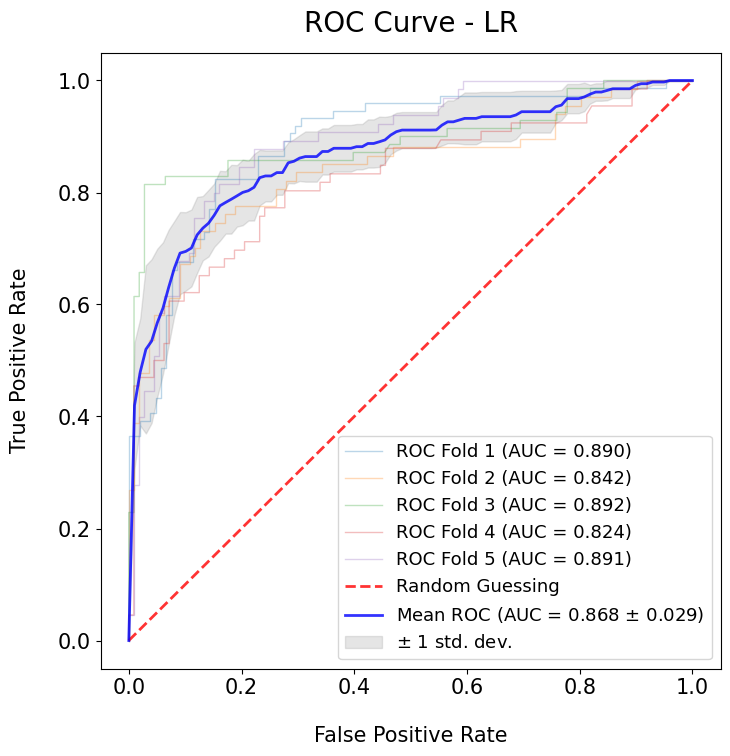


Model [LDA]:
+ params = {'covariance_estimator': None, 'n_components': None, 'priors': None, 'shrinkage': None, 'solver': 'svd', 'store_covariance': False, 'tol': 0.0001}
+ acc = [0.8212290502793296, 0.8089887640449438, 0.8764044943820225, 0.7865168539325843, 0.8370786516853933]
+ mean_acc = 0.826044 +/- 0.030114


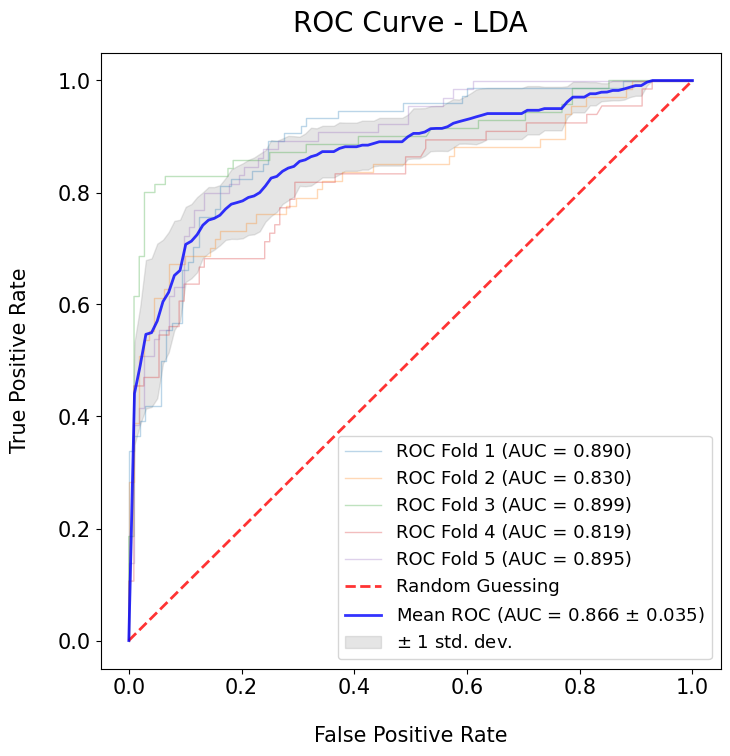


Model [RF]:
+ params = {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}
+ acc = [0.8268156424581006, 0.8146067415730337, 0.8370786516853933, 0.7640449438202247, 0.8258426966292135]
+ mean_acc = 0.813678 +/- 0.025817


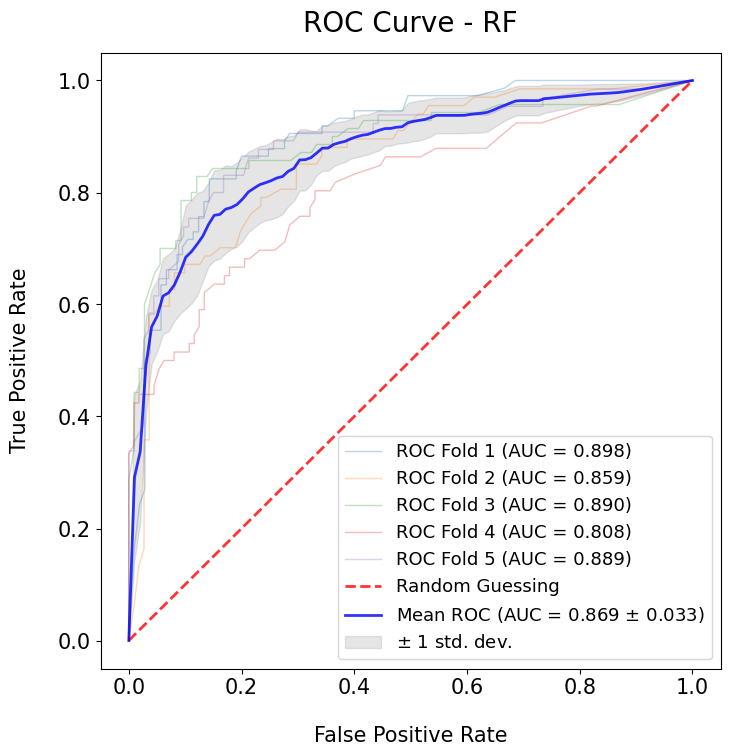

In [11]:
# Mô hình mặc định (models, results, hyper-parameters)
baseline_models  = {}
acc_results = {}
auc_results = {}

# khởi tạo các tham số mặc định
baseline_models = {
    'LR': LogisticRegression(random_state=params_cfg['seed']),
    'LDA': LinearDiscriminantAnalysis(),
    'RF': RandomForestClassifier(random_state=params_cfg['seed']),
}

# Huấn luyện từng mô hình cơ sở
for model_name in baseline_models:

    acc_results[model_name] = []
    auc_results[model_name] = []
    fprs = []
    tprs = []

    print(f'Model [{model_name}]:')

    # Chiến lược chia dữ liệu trên tập X_train
    kfold = KFold(n_splits=params_cfg["k_folds"], shuffle=True, random_state=params_cfg["seed"])

    for fold, (train_idx, valid_idx) in enumerate(kfold.split(X_train, y_train)):
        # Chia 2 tập thành train/valid
        X1_train, y1_train = X_train.iloc[train_idx], y_train.iloc[train_idx]
        X1_valid, y1_valid = X_train.iloc[valid_idx], y_train.iloc[valid_idx]

        # Lấy mô hình khởi tạo
        model_clf = sklearn.base.clone(baseline_models[model_name])
        pipe = Pipeline(steps=[('preprocessor', preprocessor_pipeline),
                               ('model', model_clf)])
        # Huấn luyện mô hình
        pipe.fit(X1_train, y1_train)

        # Lượng giá mô hình
        y1_pred_valid = pipe.predict(X1_valid)
        y1_prob_valid = pipe.predict_proba(X1_valid)[:, 1]

        # Tính toán metrics: accuracy
        valid_acc = accuracy_score(y1_valid, y1_pred_valid)
        acc_results[model_name].append(valid_acc)
        
        fpr, tpr, _ = roc_curve(y1_valid, y1_prob_valid)
        fprs.append(fpr)
        tprs.append(tpr)

        pass

    print(f'+ params = {baseline_models[model_name].get_params()}')
    print(f'+ acc = {acc_results[model_name]}')

    # trung bình kết quả +/ std cho tất cả các fold,
    # std: độ lệch chuẩn=> nếu cùng mean thì độ lệch nào nhỏ hơn thì tốt hơn vì ổn định và tập trung hơn
    s_msg = f'+ mean_acc = {np.mean(acc_results[model_name]):.6f} +/- {np.std(acc_results[model_name]):.6f}'
    print(s_msg)
    evaluation.plot_roc_curve(fprs=fprs, tprs=tprs, title=f'ROC Curve - {model_name}')
    print()

    # Huấn luyện lại với trên toàn bộ dữ liệu train (re-fit all train_data)
    pipe = Pipeline(steps=[('preprocessor', preprocessor_pipeline),
                               ('model', baseline_models[model_name])])
    pipe.fit(X_train, y_train)
    pass # model

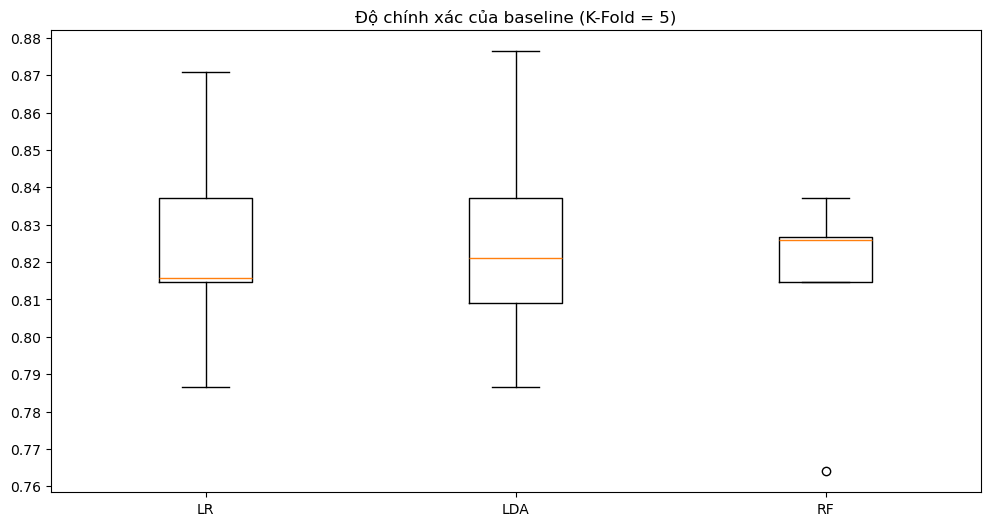

In [12]:
plt.figure(figsize=(12,6))
plt.boxplot(acc_results.values())
plt.gca().set_xticklabels(acc_results.keys())
plt.gca().yaxis.set_major_locator(ticker.MultipleLocator(0.01))
plt.title(f'Độ chính xác của baseline (K-Fold = {params_cfg['k_folds']})')
plt.show()

### 6.2 Tinh chỉnh mô hình

In [13]:
tuning_results = {
    "best_clf"   : {},
    "best_score" : {},
}

tuning_models  = {}
tuning_params  = {}

# khởi tạo các tham số mặc định
# LR
tuning_models['LR']  = Pipeline(steps=[
    ('preprocessor', preprocessor_pipeline),
    ('model', LogisticRegression(
        random_state=params_cfg['seed']
    ))
])
tuning_params['LR']  = {
    'model__C': [0.1, 1, 10],
    'model__penalty': ['l1', 'l2'],
    'model__solver': ['liblinear']
}

# LDA
tuning_models['LDA']  = Pipeline(steps=[
    ('preprocessor', preprocessor_pipeline),
    ('model', LinearDiscriminantAnalysis())
])
tuning_params['LDA']  = {
    'model__solver': ['svd', 'lsqr', 'eigen']
}

# RF
tuning_models['RF']  = Pipeline(steps=[
    ('preprocessor', preprocessor_pipeline),
    ('model', RandomForestClassifier(
        random_state = params_cfg['seed']
    ))
])
tuning_params['RF']  = {
    'model__n_estimators': [50, 100, 200],
    'model__max_depth': [None, 5, 10],
    'model__min_samples_split': [2, 5, 10],
}

for model_name in tuning_models:
    model_clf = tuning_models[model_name]

    print(f'Model [{model_name}]:')

    kfold = KFold(n_splits=params_cfg["k_folds"], shuffle=True, random_state=params_cfg["seed"])

    grid_clf = GridSearchCV(estimator=model_clf,
                            param_grid=tuning_params[model_name],
                            cv = kfold, scoring="accuracy", n_jobs=-1)
    grid_result = grid_clf.fit(X_train, y_train)

    # store best model
    tuning_results["best_clf"][model_name] = grid_clf.best_estimator_
    joblib.dump(grid_clf.best_estimator_, f'{params_cfg["save_dir"]}/model_{model_name}.joblib')   

    # get search results
    tuning_results["best_score"][model_name] = grid_result.best_score_


    # information
    print(f'+ Best score: {grid_result.best_score_}')
    print(f'+ Best turnning params: {grid_result.best_params_}')
    print()

    pass

Model [LR]:
+ Best score: 0.8305191136777352
+ Best turnning params: {'model__C': 10, 'model__penalty': 'l2', 'model__solver': 'liblinear'}

Model [LDA]:
+ Best score: 0.8271734354403364
+ Best turnning params: {'model__solver': 'lsqr'}

Model [RF]:
+ Best score: 0.8372606867114432
+ Best turnning params: {'model__max_depth': 10, 'model__min_samples_split': 5, 'model__n_estimators': 100}



## 7. Huấn luyện mô hình

In [14]:
kf = KFold(n_splits=params_cfg["k_folds"], shuffle=True, random_state=params_cfg["seed"])

def get_oof_preds(clf, X, y, X_test, kf):
    oof_train = np.zeros((X.shape[0], 2))   # 2 classes, lưu prob
    oof_test = np.zeros((X_test.shape[0], kf.n_splits, 2))
    for i, (train_idx, val_idx) in enumerate(kf.split(X, y)):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
        clf.fit(X_tr, y_tr)
        oof_train[val_idx] = clf.predict_proba(X_val)
        oof_test[:, i, :] = clf.predict_proba(X_test)
    oof_test_mean = oof_test.mean(axis=1)
    return oof_train, oof_test_mean

In [15]:
X = pd.read_excel(f'{params_cfg["save_dir"]}/data_train.xlsx')
X_train = X.drop(columns='Survived')
y_train = X['Survived'].astype(int)
X_test = pd.read_excel(f'{params_cfg["save_dir"]}/data_test.xlsx')
print(f'+ X_train: {X_train.shape}')
display.display(X_train.head())
print(f'+ X_test: {X_test.shape}')
display.display(X_test.head())

+ X_train: (891, 13)


,Age,Fare,Embarked,Cabin,Pclass,SibSp,Parch,Sex,FamilySize,IsAlone,TitleGroup,AgeBin,FareBin
0,22.0,7.2500,S,U,3,1,0,male,2,0,Mr,2,0
1,38.0,71.2833,C,C,1,1,0,female,2,0,Mrs,3,1
2,26.0,7.9250,S,U,3,0,0,female,1,1,Miss,2,0
3,35.0,53.1000,S,C,1,1,0,female,2,0,Mrs,3,1
4,35.0,8.0500,S,U,3,0,0,male,1,1,Mr,3,0


+ X_test: (418, 13)


,Age,Fare,Embarked,Cabin,Pclass,SibSp,Parch,Sex,FamilySize,IsAlone,TitleGroup,AgeBin,FareBin
0,34.5,7.8292,Q,U,3,0,0,male,1,1,Mr,3,0
1,47.0,7.0000,S,U,3,1,0,female,2,0,Mrs,3,0
2,62.0,9.6875,Q,U,2,0,0,male,1,1,Mr,4,0
3,27.0,8.6625,S,U,3,0,0,male,1,1,Mr,2,0
4,22.0,12.2875,S,U,3,1,1,female,3,0,Mrs,2,0


In [16]:
def create_submission(preds, filename='submission.csv'):
    id = pd.read_csv(f'{params_cfg["data_dir"]}/test.csv')['PassengerId'].astype(int)
    submission_df = pd.DataFrame({'PassengerId': id, 'Survived': preds.astype(int)})
    submission_df.to_csv(f'{params_cfg["output_dir"]}/{filename}', index=False)

### 7.1 Weighted averaging (LDA, RF, LR) ~ Accuracy: 0.78229

In [17]:
lda = tuning_results["best_clf"]['LDA']
rf = tuning_results["best_clf"]['RF']
lr = tuning_results["best_clf"]['LR']

oof_lda, test_lda = get_oof_preds(lda, X_train, y_train, X_test, kf)
oof_rf, test_rf = get_oof_preds(rf, X_train, y_train, X_test, kf)
oof_lr, test_lr = get_oof_preds(lr, X_train, y_train, X_test, kf)

# Weighted average
w_lda, w_rf, w_lr = 0.45, 0.3, 0.25
weighted_train_pos = w_lda*oof_lda[:,1] + w_rf*oof_rf[:,1] + w_lr*oof_lr[:,1]
weighted_test_pos = w_lda*test_lda[:,1] + w_rf*test_rf[:,1] + w_lr*test_lr[:,1]

# Chuyển về label (threshold 0.5)
preds_train_label = (weighted_train_pos >= 0.5).astype(int)
preds_label = (weighted_test_pos >= 0.5).astype(int)

# Tạo file submission
print(f'Accuracy Weighted Average: {accuracy_score(y_train, preds_train_label):.6f}')
create_submission(preds_label, filename='submission_weighted_average.csv')

Accuracy Weighted Average: 0.829405


### 7.2 Stacking LDA, RF, LR + LogisticRegression (0.77273)

In [18]:
oof_train_stack = np.column_stack([
    oof_lda[:,1],
    oof_rf[:,1],
    oof_lr[:,1]
])

oof_test_stack = np.column_stack([
    test_lda[:,1],
    test_rf[:,1],
    test_lr[:,1]
])

# 2) Train meta-model trên OOF train
meta = LogisticRegression(C=1.0, penalty='l2', solver='lbfgs', max_iter=2000, random_state=42)
meta.fit(oof_train_stack, y_train)

# Eval meta via CV on OOF (optional)
meta_pred_val = meta.predict(oof_train_stack)
print(f"Meta OOF accuracy: {accuracy_score(y_train, meta_pred_val):.6f}")

# 3) Dự đoán test
final_test_prob = meta.predict_proba(oof_test_stack)[:,1]
final_test_label = (final_test_prob >= 0.5).astype(int)
create_submission(final_test_label, filename='submission_stacking_oof.csv')

Meta OOF accuracy: 0.837262


### 7.3 Voting LDA, RF (0.77990)

In [37]:
from sklearn.ensemble import VotingClassifier

voting = VotingClassifier(
    estimators=[('lda', lda), ('rf', rf)],
    voting='soft',
    weights=[2, 1]
)
# Train-validation split for evaluation
X_trn, X_val, y_trn, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=params_cfg['seed'])
voting.fit(X_trn, y_trn)
val_preds = voting.predict(X_val)
print(f'Voting Classifier Validation Accuracy: {accuracy_score(y_val, val_preds):.6f}')
# Fit on full training data and predict test set
voting.fit(X_train, y_train)
preds = voting.predict(X_test)
create_submission(preds, filename='submission_voting.csv')

Voting Classifier Validation Accuracy: 0.821229


# Kết thúc